# Silica — versión mínima

Predecir `% Silica Concentrate` a 1, 3, 6 y 12 horas vista.

**Cinco pasos:**
1. Cargar el CSV
2. Agregar a hora
3. Cortar donde hay huecos
4. Lags y targets
5. Entrenar PLS y XGBoost, comparar contra persistencia

Nada más. Cuando esto funcione, se mejora por partes.

## 1. Cargar

In [52]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

warnings.filterwarnings("ignore")

DATA_PATH = Path("../Datasets/MiningProcess_Flotation_Plant_Database.csv")
TIME   = "date"
TARGET = "% Silica Concentrate"

HORIZONTES = [1, 3]   # horas
LAGS       = [1, 2, 3]

GAP_LIMIT_HORAS   = 3          # salto > 3 h -> corta bloque
FROZEN_MIN_HORAS  = 12         # variable congelada >= 12 h -> sensor muerto

VARIABLES_NO_CONSIDERADAS = ['% Iron Feed', '% Iron Concentrate']

data = pd.read_csv(DATA_PATH)
data[TIME] = pd.to_datetime(data[TIME])

# El CSV usa coma decimal
for c in data.select_dtypes(include=["object"]).columns:
    data[c] = pd.to_numeric(data[c].astype(str).str.replace(",", "."),
                            errors="coerce")

data = data.sort_values(TIME).reset_index(drop=True)
print(f"{len(data):,} filas | {data[TIME].min()} -> {data[TIME].max()}")

737,453 filas | 2017-03-10 01:00:00 -> 2017-09-09 23:00:00


## 2. Agregar a hora

El target es un análisis de laboratorio horario. Las features sí varían dentro de la
hora, así que se resumen con media y desviación.

In [53]:
features_base = [c for c in data.columns if c not in (TIME, TARGET) and c not in VARIABLES_NO_CONSIDERADAS]

spec = {TARGET: "median"}
for c in features_base:
    spec[c] = ["mean", "std"]

h = data.groupby(TIME).agg(spec)
h.columns = [a if b in ("median", "") else f"{a}_{b}" for a, b in h.columns]
h = h.fillna(0).reset_index()

print(f"{len(data):,} filas -> {len(h):,} horas | {h.shape[1]} columnas")
h.head(3)

737,453 filas -> 4,097 horas | 42 columnas


,date,% Silica Concentrate,% Silica Feed_mean,% Silica Feed_std,Starch Flow_mean,Starch Flow_std,Amina Flow_mean,Amina Flow_std,Ore Pulp Flow_mean,Ore Pulp Flow_std,...,Flotation Column 03 Level_mean,Flotation Column 03 Level_std,Flotation Column 04 Level_mean,Flotation Column 04 Level_std,Flotation Column 05 Level_mean,Flotation Column 05 Level_std,Flotation Column 06 Level_mean,Flotation Column 06 Level_std,Flotation Column 07 Level_mean,Flotation Column 07 Level_std
0,2017-03-10 01:00:00,1.31,16.98,0.0,3162.625026,550.741660,578.786678,19.985162,398.753368,4.742481,...,450.474523,11.917634,449.912259,27.385709,455.792161,28.046224,464.383310,30.091768,450.532747,42.397221
1,2017-03-10 02:00:00,1.11,16.98,0.0,3133.256389,511.766781,537.219661,21.517606,399.871822,4.100871,...,450.081222,7.568587,450.328806,19.554887,448.722983,31.191553,455.501528,19.413047,451.387700,35.961193
2,2017-03-10 03:00:00,1.27,16.98,0.0,3479.482944,154.079107,591.906744,8.795228,398.763806,4.176518,...,450.901822,10.279704,451.145822,21.160415,451.134189,31.249577,459.981311,24.794114,450.296722,37.799090


## 3. Cortar donde hay huecos

Si la planta paró tres días, no se puede calcular un lag que cruce ese hueco. Cada tramo
continuo se marca con un `bloque` distinto.

In [54]:
GAP_HORAS = 3

salto = h[TIME].diff() > pd.Timedelta(hours=GAP_HORAS)
h["bloque"] = salto.cumsum()

print(h.groupby("bloque").size().to_string())

bloque
0     149
1    3948


# Eliminar huecos donde la variable target esté estancada

In [55]:
def detectar_congelados(df, columnas, min_horas=FROZEN_MIN_HORAS,
                        col=TIME):
    """Tramos donde una variable no cambia durante min_horas consecutivas."""
    rangos = []
    for var in columnas:
        quieto = df[var].diff().eq(0)
        grupo = (quieto != quieto.shift()).cumsum()
        runs = (df.assign(_g=grupo, _q=quieto)
                  .groupby("_g")
                  .agg(inicio=(col, "first"), fin=(col, "last"),
                       n=(col, "size"), quieto=("_q", "first"),
                       valor=(var, "first")))
        for _, r in runs[(runs["quieto"]) & (runs["n"] >= min_horas)].iterrows():
            print(f"{var:<35} congelado en {r['valor']:>9.3f} | "
                  f"{r['inicio']} -> {r['fin']} ({int(r['n'])} h)")
            rangos.append((r["inicio"], r["fin"]))
    return rangos


# Ahora se vigilan TODAS las medias, no solo % Silica Feed
cols_mean = [c for c in h.columns if c.endswith("_mean")]
rangos_muertos = detectar_congelados(h, cols_mean + [TARGET])
print(f"\nTramos inválidos detectados: {len(rangos_muertos)}")

% Silica Feed_mean                  congelado en    11.460 | 2017-03-12 02:00:00 -> 2017-03-12 15:00:00 (14 h)
% Silica Feed_mean                  congelado en    10.840 | 2017-03-14 17:00:00 -> 2017-03-15 06:00:00 (14 h)
% Silica Feed_mean                  congelado en     9.220 | 2017-03-31 08:00:00 -> 2017-04-02 06:00:00 (47 h)
% Silica Feed_mean                  congelado en    17.410 | 2017-04-03 08:00:00 -> 2017-04-04 00:00:00 (17 h)
% Silica Feed_mean                  congelado en    13.530 | 2017-04-09 08:00:00 -> 2017-04-09 23:00:00 (16 h)
% Silica Feed_mean                  congelado en    13.470 | 2017-04-11 02:00:00 -> 2017-04-11 15:00:00 (14 h)
% Silica Feed_mean                  congelado en    13.040 | 2017-04-19 02:00:00 -> 2017-04-19 15:00:00 (14 h)
% Silica Feed_mean                  congelado en    23.800 | 2017-04-20 17:00:00 -> 2017-04-21 06:00:00 (14 h)
% Silica Feed_mean                  congelado en    14.350 | 2017-04-21 08:00:00 -> 2017-04-24 06:00:00 (71 h)
%

# Eliminar los bloques en los cuales no se modifican variables de interés

In [56]:
variables_con_bloques_a_eliminar = ['% Silica Concentrate', '% Silica Feed_mean']

def partir_en_bloques(df, rangos_invalidos, col=TIME,
                      limite_horas=GAP_LIMIT_HORAS, min_filas=MIN_BLOCK_HORAS):
    valida = pd.Series(True, index=df.index)
    for inicio, fin in rangos_invalidos:
        valida &= ~((df[col] >= inicio) & (df[col] <= fin))

    hueco = df[col].diff() > pd.Timedelta(hours=limite_horas)
    corte = (~valida | hueco).cumsum()

    return [g.reset_index(drop=True)
            for _, g in df[valida].groupby(corte[valida])
            if len(g) >= min_filas]


bloques = partir_en_bloques(h, rangos_muertos)

print(f"Bloques válidos: {len(bloques)}\n")
for i, b in enumerate(bloques):
    print(f"  [{i}] {len(b):>5} h ({len(b)/24:>5.1f} días) | "
          f"{b[TIME].min()} -> {b[TIME].max()}")

total_horas = sum(len(b) for b in bloques)
print(f"\nHoras conservadas: {total_horas:,} de {len(h):,} "
      f"({total_horas/len(h):.1%})")

NameError: name 'MIN_BLOCK_HORAS' is not defined

## 4. Lags y targets

- **Lags:** el valor de cada variable 1, 2, 3, 6 y 12 horas antes.
- **Targets:** el valor de la sílice 1, 3, 6 y 12 horas *después*.

Ambos se calculan dentro de cada bloque, para que no crucen un hueco.

In [46]:
def construir(bloque):
    out = bloque.copy()
    variables = [c for c in out.columns if c not in (TIME, "bloque")]

    nuevas = {}
    for v in variables:
        for L in LAGS:
            nuevas[f"{v}_lag{L}"] = out[v].shift(L)
    out = pd.concat([out, pd.DataFrame(nuevas, index=out.index)], axis=1)

    for H in HORIZONTES:
        out[f"target_{H}h"] = out[TARGET].shift(-H)

    return out


df = pd.concat([construir(g) for _, g in h.groupby("bloque")], ignore_index=True)

TARGETS  = [f"target_{H}h" for H in HORIZONTES]
FEATURES = [c for c in df.columns if c not in TARGETS + [TIME, "bloque"]]

print(f"{len(df):,} filas | {len(FEATURES)} features")
print(f"Ratio muestras/feature: {len(df)/len(FEATURES):.1f}")

4,097 filas | 164 features
Ratio muestras/feature: 25.0


In [47]:
# Comprobación: todo lo que va al modelo tiene que ser numérico
malas = [c for c in FEATURES if not pd.api.types.is_numeric_dtype(df[c])]
assert not malas, f"Features no numéricas: {malas}"
print("Features OK")

Features OK


## 5. Entrenar y comparar

**Split cronológico:** el test es el último 20 % en el tiempo. Nada de barajar — con una
serie temporal, barajar mete el futuro dentro del entrenamiento.

**Persistencia** es el rival a batir: predecir que dentro de H horas la sílice será la
misma que ahora. Si un modelo no gana a eso, no sirve.

In [48]:
def split(H):
    col = f"target_{H}h"
    d = df.dropna(subset=FEATURES + [col]).reset_index(drop=True)
    corte = int(len(d) * 0.8)
    return d.iloc[:corte - H], d.iloc[corte:], col


resultados = []
predicciones = {}

for H in HORIZONTES:
    tr, te, col = split(H)

    # --- Persistencia ---
    pred_p = te[TARGET].to_numpy()

    # --- PLS ---
    pls = Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=10, scale=False)),
    ]).fit(tr[FEATURES], tr[col])
    pred_pls = pls.predict(te[FEATURES]).ravel()

    # --- XGBoost ---
    modelo = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42, n_jobs=-1,
    ).fit(tr[FEATURES], tr[col])
    pred_xgb = modelo.predict(te[FEATURES])

    y = te[col].to_numpy()
    for nombre, p in [("Persistencia", pred_p), ("PLS", pred_pls),
                      ("XGBoost", pred_xgb)]:
        resultados.append({
            "horizonte": H,
            "modelo": nombre,
            "RMSE": root_mean_squared_error(y, p),
            "R2": r2_score(y, p),
        })

    predicciones[H] = (te, col, pred_pls, pred_xgb)
    print(f"h={H:>2} | train={len(tr):>5} test={len(te):>5}")

h= 1 | train= 3270 test=  818
h= 3 | train= 3265 test=  817


In [49]:
tabla = pd.DataFrame(resultados).pivot(index="horizonte", columns="modelo",
                                       values="RMSE")
tabla["PLS_mejora_%"] = (tabla["Persistencia"] - tabla["PLS"]) / tabla["Persistencia"] * 100
tabla["XGB_mejora_%"] = (tabla["Persistencia"] - tabla["XGBoost"]) / tabla["Persistencia"] * 100

print("RMSE por horizonte (menor = mejor)")
print(tabla.round(4).to_string())

RMSE por horizonte (menor = mejor)
modelo        PLS  Persistencia  XGBoost  PLS_mejora_%  XGB_mejora_%
horizonte                                                           
1          0.7145        0.7134   0.7153       -0.1535       -0.2661
3          0.9861        0.9955   0.9520        0.9488        4.3763


**Las dos últimas columnas son el veredicto.** Positivo = el modelo gana a no hacer
nada. Negativo = pierde, y no sirve para ese horizonte.

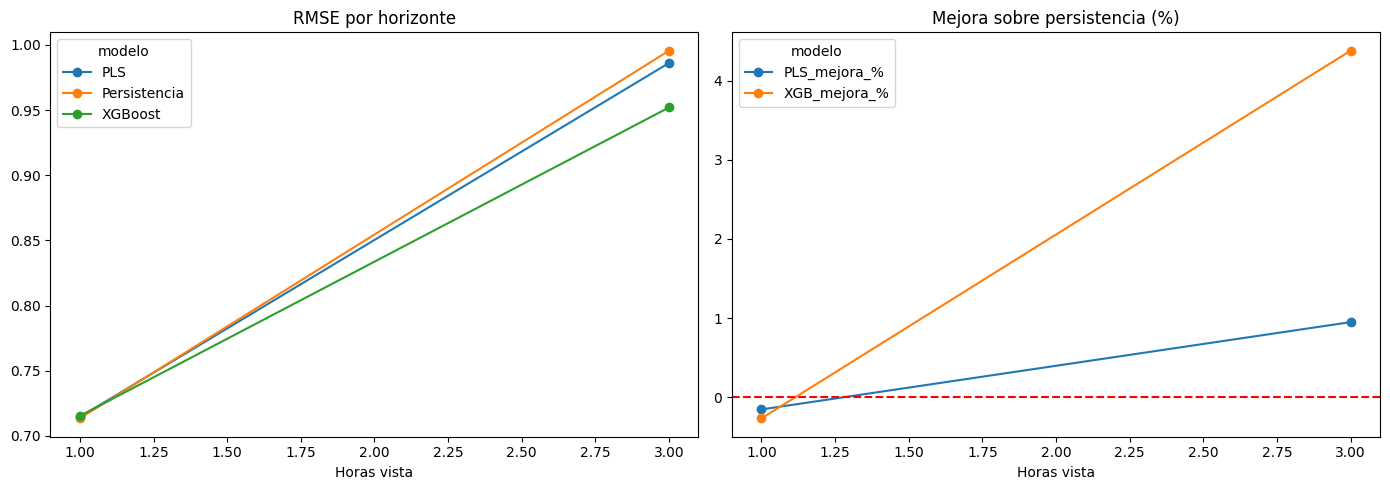

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.DataFrame(resultados).pivot(index="horizonte", columns="modelo",
                               values="RMSE").plot(marker="o", ax=axes[0])
axes[0].set_title("RMSE por horizonte")
axes[0].set_xlabel("Horas vista")

tabla[["PLS_mejora_%", "XGB_mejora_%"]].plot(marker="o", ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Mejora sobre persistencia (%)")
axes[1].set_xlabel("Horas vista")

plt.tight_layout()
plt.show()

In [51]:
H = 6   # cambia para ver otro horizonte
te, col, pred_pls, pred_xgb = predicciones[H]

fig, ax = plt.subplots(figsize=(15, 5))
n = 300
ax.plot(te[TIME][:n], te[col][:n], label="Real", color="#1f77b4", linewidth=1.4)
ax.plot(te[TIME][:n], pred_pls[:n], label="PLS", color="#2ca02c", alpha=0.8)
ax.plot(te[TIME][:n], pred_xgb[:n], label="XGBoost", color="#ff7f0e", alpha=0.8)
ax.plot(te[TIME][:n], te[TARGET][:n], label="Persistencia", color="gray",
        linestyle="--", alpha=0.6)
ax.set_title(f"Horizonte {H} h")
ax.legend()
plt.tight_layout()
plt.show()

KeyError: 6

## Qué mirar

- ¿Gana alguno a la persistencia? ¿En qué horizontes?
- ¿Va alguna predicción retrasada respecto a la línea azul? Eso es copiar el pasado, no
  predecir.

## Siguientes pasos, de uno en uno

1. Ajustar el número de componentes del PLS (ahora está fijo en 10)
2. Ajustar los hiperparámetros de XGBoost
3. Mirar qué variables pesan más
4. Ventana móvil: reentrenar periódicamente en vez de una sola vez